In [27]:
import os
from dotenv import load_dotenv

load_dotenv("/Users/azeemkhalipha/mlops-demand-forecast/.env")

os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@17"
os.environ["PATH"] = "/opt/homebrew/opt/openjdk@17/bin:" + os.environ["PATH"]

PROJECT_ROOT = os.getenv("PROJECT_ROOT")
FEATURES_PATH = f"{PROJECT_ROOT}/data/features"
MLFLOW_PATH = f"file://{PROJECT_ROOT}/mlruns"

# print(f"Project root: {FEATURES_PATH}")

python-dotenv could not parse statement starting at line 1


In [28]:
import mlflow
import pandas as pd

# Point MLflow to your local project folder
mlflow.set_tracking_uri(f"file://{PROJECT_ROOT}/mlruns")
mlflow.set_experiment("demand_forecasting")

# Load the feature parquet you saved in Week 1
df = pd.read_parquet(f"{FEATURES_PATH}/ml_features")

print(f"Feature dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nSample:\n{df.head(3)}")

Feature dataset shape: (330546, 10)

Columns: ['StockCode', 'invoice_date', 'daily_qty', 'daily_revenue', 'qty_lag_1', 'qty_lag_7', 'qty_lag_30', 'qty_rolling_avg_7', 'qty_rolling_avg_30', 'qty_rolling_std_7']

Sample:
  StockCode invoice_date  daily_qty  daily_revenue  qty_lag_1  qty_lag_7  \
0     10133   2010-04-28         10            8.5         10          5   
1     10133   2010-04-29          4            3.4         10          1   
2     10133   2010-05-10         30           25.5          4          3   

   qty_lag_30  qty_rolling_avg_7  qty_rolling_avg_30  qty_rolling_std_7  
0           6           5.714286           15.866667           4.231402  
1          40           6.428571           16.000000           4.503967  
2          24           6.857143           14.800000           4.017817  


In [29]:
# Log a test run to verify MLflow is set up correctly
with mlflow.start_run(run_name="test_run"):
    mlflow.log_param("test_param", "hello")
    mlflow.log_metric("test_metric", 0.99)
    print("MLflow test run logged successfully")

MLflow test run logged successfully


In [30]:
import numpy as np
from sklearn.model_selection import train_test_split

# Target variable: next day's quantity (what we're predicting)
df = df.sort_values(["StockCode", "invoice_date"])
df["target"] = df.groupby("StockCode")["daily_qty"].shift(-1)

# Drop rows where target is null (last day of each product)
df = df.dropna(subset=["target"])

# Select feature columns for the model
FEATURE_COLS = [
    "qty_lag_1",
    "qty_lag_7",
    "qty_lag_30",
    "qty_rolling_avg_7",
    "qty_rolling_avg_30",
    "qty_rolling_std_7",
    "daily_revenue"
]

# Drop any remaining nulls in features
df = df.dropna(subset=FEATURE_COLS)

X = df[FEATURE_COLS]
y = df["target"]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {FEATURE_COLS}")
print(f"\nTarget stats:\n{y.describe()}")

Features shape: (327619, 7)
Target shape: (327619,)

Feature columns: ['qty_lag_1', 'qty_lag_7', 'qty_lag_30', 'qty_rolling_avg_7', 'qty_rolling_avg_30', 'qty_rolling_std_7', 'daily_revenue']

Target stats:
count    327619.000000
mean         24.438119
std          81.867953
min           1.000000
25%           3.000000
50%          10.000000
75%          24.000000
max       11124.000000
Name: target, dtype: float64


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Train size: {X_train.shape[0]:,} rows")
print(f"Test size:  {X_test.shape[0]:,} rows")

Train size: 262,095 rows
Test size:  65,524 rows


Linear Regression

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate_model(model, X_test, y_test):
    preds = model.predict(X_test)
    mae   = mean_absolute_error(y_test, preds)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    r2    = r2_score(y_test, preds)
    return {"mae": mae, "rmse": rmse, "r2": r2, "predictions": preds}

# Train and log to MLflow
with mlflow.start_run(run_name="linear_regression_baseline"):

    model = LinearRegression()
    model.fit(X_train, y_train)

    metrics = evaluate_model(model, X_test, y_test)

    # Log params
    mlflow.log_param("model_type",   "LinearRegression")
    mlflow.log_param("feature_cols", str(FEATURE_COLS))
    mlflow.log_param("train_size",   len(X_train))
    mlflow.log_param("test_size",    len(X_test))

    # Log metrics
    mlflow.log_metric("mae",  metrics["mae"])
    mlflow.log_metric("rmse", metrics["rmse"])
    mlflow.log_metric("r2",   metrics["r2"])

    # Log the model itself
    mlflow.sklearn.log_model(model, "model")

    print(f"Linear Regression Results:")
    print(f"  MAE:  {metrics['mae']:.4f}")
    print(f"  RMSE: {metrics['rmse']:.4f}")
    print(f"  R2:   {metrics['r2']:.4f}")

2026/05/16 22:44:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/16 22:44:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Linear Regression Results:
  MAE:  21.1685
  RMSE: 70.0063
  R2:   0.1082


XGBoost with hyperparameter logging

2026/05/16 22:45:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


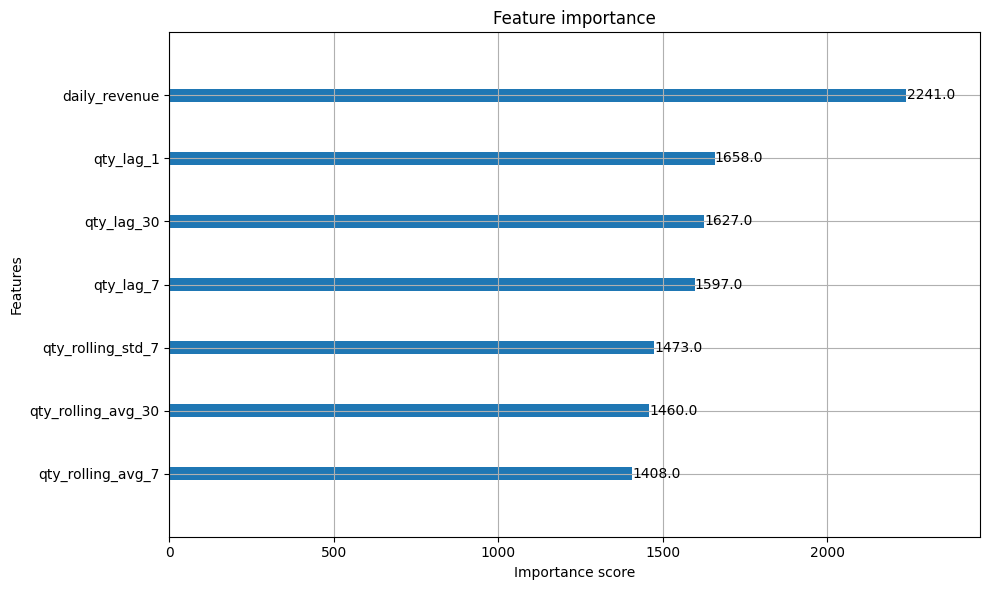

XGBoost Results:
  MAE:  21.5370
  RMSE: 73.2052
  R2:   0.0249


In [33]:
import xgboost as xgb

with mlflow.start_run(run_name="xgboost_v1"):

    params = {
        "n_estimators":     200,
        "max_depth":        6,
        "learning_rate":    0.1,
        "subsample":        0.8,
        "colsample_bytree": 0.8,
        "random_state":     42
    }

    model = xgb.XGBRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    metrics = evaluate_model(model, X_test, y_test)

    # Log everything to MLflow
    mlflow.log_params(params)
    mlflow.log_metric("mae",  metrics["mae"])
    mlflow.log_metric("rmse", metrics["rmse"])
    mlflow.log_metric("r2",   metrics["r2"])
    mlflow.xgboost.log_model(model, "model")

    # Log feature importance as a plot
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(10, 6))
    xgb.plot_importance(model, ax=ax, max_num_features=10)
    plt.tight_layout()
    mlflow.log_figure(fig, "feature_importance.png")
    plt.show()

    print(f"XGBoost Results:")
    print(f"  MAE:  {metrics['mae']:.4f}")
    print(f"  RMSE: {metrics['rmse']:.4f}")
    print(f"  R2:   {metrics['r2']:.4f}")

LightGBM

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000951 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1785
[LightGBM] [Info] Number of data points in the train set: 262095, number of used features: 7
[LightGBM] [Info] Start training from score 24.470020
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

2026/05/16 22:45:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/16 22:45:07 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


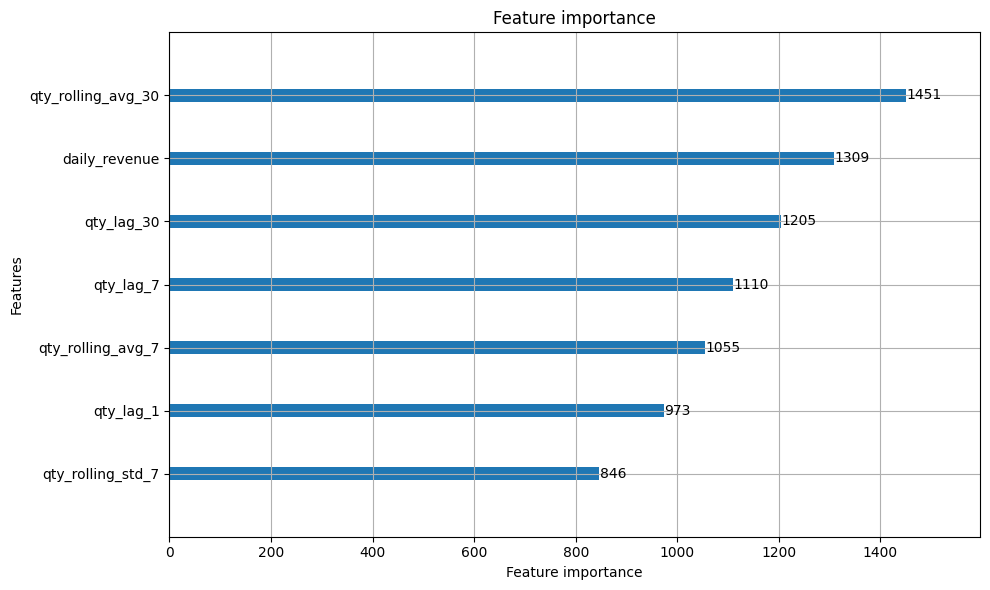

LightGBM Results:
  MAE:  21.2958
  RMSE: 71.0190
  R2:   0.0822


In [34]:
import lightgbm as lgb

with mlflow.start_run(run_name="lightgbm_v1"):

    params = {
        "n_estimators":  300,
        "max_depth":     6,
        "learning_rate": 0.05,
        "num_leaves":    31,
        "subsample":     0.8,
        "random_state":  42
    }

    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
    )

    metrics = evaluate_model(model, X_test, y_test)

    mlflow.log_params(params)
    mlflow.log_metric("mae",  metrics["mae"])
    mlflow.log_metric("rmse", metrics["rmse"])
    mlflow.log_metric("r2",   metrics["r2"])
    mlflow.lightgbm.log_model(model, "model")

    # Feature importance plot
    fig, ax = plt.subplots(figsize=(10, 6))
    lgb.plot_importance(model, ax=ax, max_num_features=10)
    plt.tight_layout()
    mlflow.log_figure(fig, "feature_importance.png")
    plt.show()

    print(f"LightGBM Results:")
    print(f"  MAE:  {metrics['mae']:.4f}")
    print(f"  RMSE: {metrics['rmse']:.4f}")
    print(f"  R2:   {metrics['r2']:.4f}")

In [35]:
# Fetch all runs from MLflow
runs = mlflow.search_runs(
    experiment_names=["demand_forecasting"],
    filter_string="tags.mlflow.runName != 'test_run'"
)


runs = runs.sort_values("start_time", ascending=False)
runs = runs.drop_duplicates(subset=["tags.mlflow.runName"], keep="first")

# Show comparison table
comparison = runs[[
    "tags.mlflow.runName",
    "metrics.mae",
    "metrics.rmse",
    "metrics.r2"
]].rename(columns={
    "tags.mlflow.runName": "model",
    "metrics.mae":         "MAE",
    "metrics.rmse":        "RMSE",
    "metrics.r2":          "R2"
})

comparison = comparison.sort_values("RMSE")
print("Model Comparison (sorted by RMSE):")
print(comparison.to_string(index=False))

Model Comparison (sorted by RMSE):
                     model       MAE      RMSE       R2
linear_regression_baseline 21.168460 70.006328 0.108230
      linear_regression_v2 21.168460 70.006328 0.108230
               lightgbm_v1 21.295836 71.019018 0.082243
                xgboost_v1 21.536986 73.205215 0.024870


In [36]:
# Get the best run (lowest RMSE)
best_run = runs.sort_values("metrics.rmse").iloc[0]
best_run_id   = best_run["run_id"]
best_run_name = best_run["tags.mlflow.runName"]

print(f"Best model: {best_run_name}")
print(f"Best RMSE:  {best_run['metrics.rmse']:.4f}")
print(f"Run ID:     {best_run_id}")

# Register in MLflow Model Registry
model_uri = f"runs:/{best_run_id}/model"
result = mlflow.register_model(
    model_uri,
    "demand_forecast_model"
)

print(f"\nModel registered as version: {result.version}")
print("Check it at http://localhost:5000 under Models tab")

Registered model 'demand_forecast_model' already exists. Creating a new version of this model...
2026/05/16 22:45:10 WARNING mlflow.tracking._model_registry.fluent: Run with id 3d0826d219ef4aedbf30ff87885d9579 has no artifacts at artifact path 'model', registering model based on models:/m-40e5b83498e04e26a3c956ff6b431607 instead


Best model: linear_regression_baseline
Best RMSE:  70.0063
Run ID:     3d0826d219ef4aedbf30ff87885d9579

Model registered as version: 4
Check it at http://localhost:5000 under Models tab


Created version '4' of model 'demand_forecast_model'.


In [37]:
# Load the registered model
loaded_model = mlflow.pyfunc.load_model(
    model_uri="models:/demand_forecast_model/1"
)

# Make predictions on test set
sample = X_test.head(10)
predictions = loaded_model.predict(sample)

# Compare predictions vs actual
results = pd.DataFrame({
    "actual":    y_test.head(10).values,
    "predicted": predictions.round(2)
})
results["error"] = (results["actual"] - results["predicted"]).abs().round(2)

print("Sample Predictions vs Actual:")
print(results.to_string(index=False))

Sample Predictions vs Actual:
 actual  predicted  error
   12.0      22.21  10.21
  288.0      24.66 263.34
   19.0      27.73   8.73
    4.0       9.70   5.70
   12.0      15.85   3.85
    1.0       6.20   5.20
    1.0      14.65  13.65
   12.0      17.41   5.41
    3.0       5.87   2.87
   24.0      15.57   8.43


In [38]:
os.makedirs(f"{PROJECT_ROOT}/data/predictions", exist_ok=True)

all_predictions = loaded_model.predict(X_test)
results_full = pd.DataFrame({
    "actual":    y_test.values,
    "predicted": all_predictions.round(2)
})
results_full["error"] = (
    results_full["actual"] - results_full["predicted"]
).abs().round(2)

results_full.to_parquet(
    f"{PROJECT_ROOT}/data/predictions/test_predictions.parquet",
    index=False
)

print(f"Predictions saved: {len(results_full):,} rows")
print(f"\nOverall MAE: {results_full['error'].mean():.4f}")

Predictions saved: 65,524 rows

Overall MAE: 21.1685
